In [27]:
import numpy as np
import pandas as pd

df = pd.read_csv("student_placement_100_entries.csv")

In [28]:
df = df.iloc[:,1:]
df

,cgpa,iq,placement
0,6.87,111,1
1,9.75,118,1
2,8.66,128,1
3,7.99,131,1
4,5.78,140,0
...,...,...,...
95,7.47,132,1
96,7.61,123,1
97,7.14,105,0
98,5.13,111,0


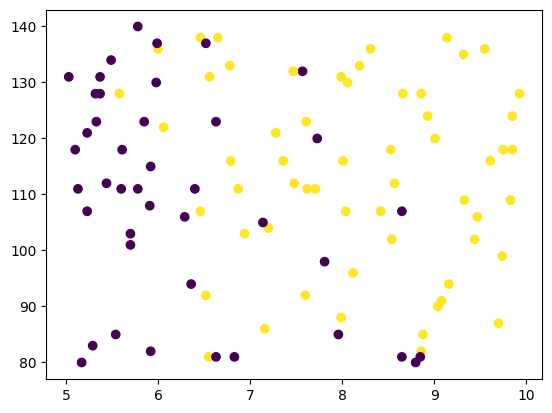

In [29]:
import matplotlib.pyplot as plt
plt.scatter(df['cgpa'], df['iq'], c=df['placement'])

In [30]:
x = df.iloc[:,0:2]
y = df.iloc[:,-1]

In [31]:
from sklearn.model_selection import train_test_split

In [32]:
xtrain, xtest, ytrain, ytest = train_test_split(
    x, y, test_size=0.1, random_state=42)

In [33]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()


In [34]:
xtrain = scaler.fit_transform(xtrain)
xtrain

array([[-0.13149109, -1.39880883],
       [ 0.46462194, -0.22952591],
       [ 1.16911915, -1.12040814],
       [ 1.61620393, -0.67496702],
       [-1.18823692, -0.00680535],
       [-1.06630471,  1.60791869],
       [ 1.0200909 , -1.62152939],
       [-1.34403919,  0.93975702],
       [ 1.22331125, -0.95336772],
       [-1.01888663,  0.66135632],
       [ 1.52814177,  0.27159535],
       [ 1.41298357, -0.5079266 ],
       [-0.91727645,  1.38519813],
       [-1.47951942, -1.73288967],
       [ 1.74491015,  0.93975702],
       [-0.97146854,  0.21591521],
       [-1.18146291,  0.38295562],
       [ 0.17333943,  0.66135632],
       [ 0.80332252, -0.5079266 ],
       [-1.57435559,  1.10679744],
       [ 1.69071805,  0.71703646],
       [ 0.16656542, -1.064728  ],
       [-0.49051371, -1.67720953],
       [ 0.41042984, -1.45448897],
       [ 0.30881967, -0.73064716],
       [-1.06630471, -0.00680535],
       [-1.1204968 , -0.45224646],
       [ 0.24107955, -0.00680535],
       [ 1.14202311,

In [35]:
xtest = scaler.transform(xtest)
xtest

array([[-1.37790925,  0.93975702],
       [ 1.43330561, -0.28520605],
       [ 1.0200909 ,  0.93975702],
       [ 0.64752025,  1.38519813],
       [-0.72083011, -0.28520605],
       [-0.10439505, -0.39656633],
       [-0.60567191, -0.22952591],
       [ 1.33169543,  1.32951799],
       [-1.5269375 ,  0.38295562],
       [-0.32793743, -0.00680535]])

In [36]:
from sklearn.linear_model import LogisticRegression
logi = LogisticRegression()

In [37]:
logi.fit(xtrain, ytrain)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [38]:
y_pred = logi.predict(xtest)

In [39]:
from sklearn.metrics import accuracy_score
print("Accuracy:", accuracy_score(ytest, y_pred))

Accuracy: 0.8


In [40]:
new_student = scaler.transform([[8, 277]])
print(logi.predict(new_student))

[1]


C:\Users\kunal\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
